In [10]:
import numpy as np
from monodromy.render import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
    SwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm
from weylchamber import c1c2c3

from gulps.gulps_decomposer import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass
from gulps.utils.invariants import GateInvariants
from gulps.utils.visualize import render_path
from monodromy.haar import expected_cost

# from gulps.synthesis_plugin import GulpsSynthesisPlugin

In [11]:
from gulps.utils.logging_config import logger

logger.setLevel("INFO")
# logger.setLevel("DEBUG")

In [12]:
def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()


# comment out what you don't want or add your own
isa = [
    (CXGate(), 1.0, "cx"),
    (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (iSwapGate(), 1.0, "iswap"),
    (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    # (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 0.0, "swap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)

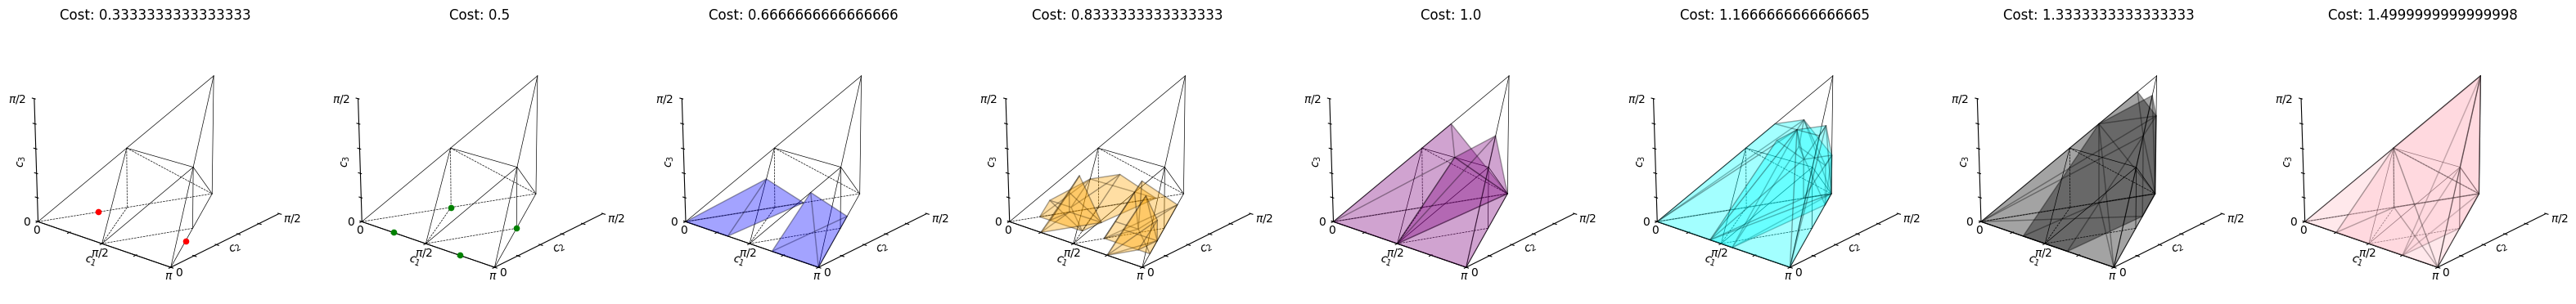

0.9482494501709955


In [13]:
if hasattr(decomposer.isa, "coverage_set"):
    _plot_coverage_set(decomposer.isa.coverage_set)
    print(expected_cost(decomposer.isa.coverage_set))

In [14]:
# NOTE warmstart
from gulps.local_numerics import SegmentNumericSynthesizer

seed = 4

u = random_unitary(4, seed=seed)
v = Operator(decomposer._run(u, easy_attempts=0, hard_attempts=1))
fid = average_gate_fidelity(u, v)
print(SegmentNumericSynthesizer._segment_stats)  # use this to make sure all [1,1,1]
hard_slow = decomposer.last_timing["numeric"]

v = Operator(decomposer._run(u, easy_attempts=1, hard_attempts=0))
fid = average_gate_fidelity(u, v)
print(SegmentNumericSynthesizer._segment_stats)  # use this to make sure all [1,1,1]
easy_fast = decomposer.last_timing["numeric"]

hard_slow / easy_fast

[gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [1.56560275e-03 1.56417521e-03 9.43698542e-09]. Proceeding with best effort.
[gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [0.00132585 0.00110185 0.00010147]. Proceeding with best effort.


[1]
[1]


7.854984060943732

In [15]:
N = 100
fidelities = []
restart_stats_easy = []

for idx in tqdm(range(N)):
    u = random_unitary(4, seed=idx)
    SegmentNumericSynthesizer._segment_stats = []  # clear before each circuit
    v = Operator(decomposer._run(u, easy_attempts=64, hard_attempts=1))
    restart_stats_easy.append(SegmentNumericSynthesizer._segment_stats.copy())
    fid = average_gate_fidelity(u, v)
    fidelities.append(fid)

    if fid < 1 - 1e-6:
        print(f"[WARN] Unitary {idx} low fidelity: {fid:.8f}")
        continue

restart_stats_hard = []

for idx in tqdm(range(N)):
    u = random_unitary(4, seed=idx)
    SegmentNumericSynthesizer._segment_stats = []  # clear before each circuit
    try:
        v = Operator(decomposer._run(u, easy_attempts=1, hard_attempts=64))
    except Exception as e:
        print(f"[ERROR] Unitary {idx} failed: {e}")
        continue
    restart_stats_hard.append(SegmentNumericSynthesizer._segment_stats.copy())
    fid = average_gate_fidelity(u, v)
    fidelities.append(fid)

    if fid < 1 - 1e-6:
        print(f"[WARN] Unitary {idx} low fidelity: {fid:.8f}")
        continue


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:09<00:00, 10.57it/s]


In [16]:
# clean restart_stats_easy and restart_stats_hard
# if a -1 is present, set to 64
for segment in restart_stats_easy:
    for i, r in enumerate(segment):
        if r == -1:
            segment[i] = 64
for segment in restart_stats_hard:
    for i, r in enumerate(segment):
        if r == -1:
            segment[i] = 64

In [17]:
filtered_hard_trials = []

for seg_easy, seg_hard in zip(restart_stats_easy, restart_stats_hard):
    for e, h in zip(seg_easy, seg_hard):
        if e > 1:
            filtered_hard_trials.append(h - 1)  # shift: attempt 2 → index 1
filtered_hard_trials = [r for r in filtered_hard_trials if r > 0]

In [18]:
1.0 / np.mean(np.array([r for segment in restart_stats_easy for r in segment]))

np.float64(0.2222222222222222)

In [19]:
1.0 / np.mean(np.array([r for segment in restart_stats_hard for r in segment]))

np.float64(0.6802721088435374)

In [20]:
1.0 / np.mean(np.array(filtered_hard_trials))

np.float64(0.3829787234042553)

Estimated success probabilities:
  Easy mode: 0.2200
  Hard mode: 0.6800


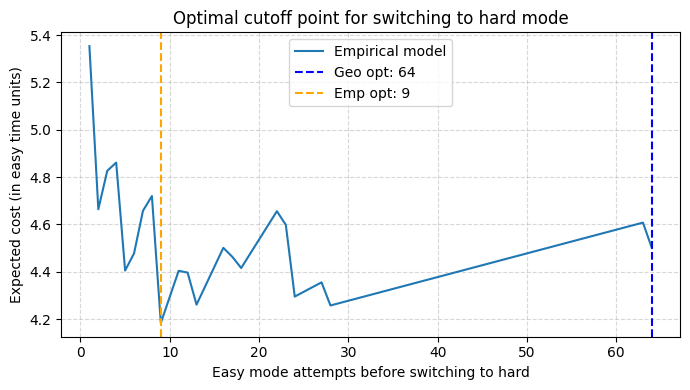

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten segment-level restarts
flat_easy = np.array([r for segment in restart_stats_easy for r in segment])
flat_hard = np.array([r for segment in restart_stats_hard for r in segment])

# Estimate success probability from empirical mean
p_easy = 0.22  # 1.0 / np.mean(flat_easy)
p_hard = 0.68  # 1.0 / np.mean(flat_hard)

print(f"Estimated success probabilities:")
print(f"  Easy mode: {p_easy:.4f}")
print(f"  Hard mode: {p_hard:.4f}")

cost_ratio = 8  # relative cost: hard is Xx more expensive than easy


# Geometric model
def expected_cost_geo(n, p_easy, p_hard, r):
    fail_prob = (1 - p_easy) ** n
    return (1 - fail_prob) / p_easy + fail_prob * (n + r / p_hard)


ns = np.arange(1, 65)
costs_geo = [expected_cost_geo(n, p_easy, p_hard, cost_ratio) for n in ns]
n_geo_opt = ns[np.argmin(costs_geo)]

# Empirical model
max_k = np.max(flat_easy)
counts = np.bincount(flat_easy, minlength=max_k + 1)[1:]
pmf = counts / counts.sum()
cdf = np.cumsum(pmf)

costs_emp = []
for n in ns:
    cum_p = cdf[n - 1] if n <= len(cdf) else 1.0
    cost_easy = sum(k * pmf[k - 1] for k in range(1, min(n, len(pmf)) + 1))
    cost_fallback = (1 - cum_p) * (n + cost_ratio / p_hard)
    costs_emp.append(cost_easy + cost_fallback)
n_emp_opt = ns[np.argmin(costs_emp)]

# Plotting
plt.figure(figsize=(7, 4))
# plt.plot(ns, costs_geo, label="Geometric model")
plt.plot(ns, costs_emp, label="Empirical model")
plt.axvline(n_geo_opt, color="blue", linestyle="--", label=f"Geo opt: {n_geo_opt}")
plt.axvline(n_emp_opt, color="orange", linestyle="--", label=f"Emp opt: {n_emp_opt}")
plt.xlabel("Easy mode attempts before switching to hard")
plt.ylabel("Expected cost (in easy time units)")
plt.title("Optimal cutoff point for switching to hard mode")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# import matplotlib.pyplot as plt
# import numpy as np

# N = 1_000
# fidelities = []
# restart_stats_optimized = []

# for idx in tqdm(range(N)):
#     u = random_unitary(4, seed=idx)
#     SegmentNumericSynthesizer._segment_stats = []  # clear before each circuit
#     v = Operator(decomposer._run(u, easy_attempts=4, hard_attempts=12))
#     restart_stats_optimized.append(SegmentNumericSynthesizer._segment_stats.copy())
#     fid = average_gate_fidelity(u, v)
#     fidelities.append(fid)

#     if fid < 1 - 1e-6:
#         print(f"[WARN] Unitary {idx} low fidelity: {fid:.8f}")
#         continue

# # Flatten restart trials into one list
# all_restarts = [r for circuit in restart_stats_optimized for r in circuit]
# # if has -1, set to 12
# for i, r in enumerate(all_restarts):
#     if r == -1:
#         all_restarts[i] = 12  # set to 12 if -1 is present

# # Parameters
# EASY_THRESHOLD = 4
# max_bin = max(all_restarts, default=0)
# bins = np.arange(1, max_bin + 2) - 0.5

# # Count how many times each restart number occurred
# counts = np.bincount(all_restarts, minlength=max_bin + 1)[1:]
# x = np.arange(1, len(counts) + 1)

# # Split counts into easy vs hard phase
# counts_easy = np.where(x <= EASY_THRESHOLD, counts, 0)
# counts_hard = np.where(x > EASY_THRESHOLD, counts, 0)

# # Plot
# plt.figure(figsize=(8, 4))
# plt.bar(x, counts_easy, color="#6baed6", edgecolor="black", label="Easy phase")
# plt.bar(
#     x,
#     counts_hard,
#     color="#fd8d3c",
#     edgecolor="black",
#     label="Hard phase",
#     bottom=counts_easy,
# )
# plt.axvline(
#     EASY_THRESHOLD + 0.5, linestyle="--", color="gray", label="Easy/Hard cutoff"
# )

# plt.xlabel("Restart number for segment success")
# plt.ylabel("Segment count")
# plt.title("Histogram of restart attempts per segment")
# plt.xticks(np.arange(1, max_bin + 1))
# plt.grid(axis="y", linestyle="--", alpha=0.5)
# plt.legend()
# plt.tight_layout()
# plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

 59%|█████▉    | 594/1000 [00:56<00:38, 10.44it/s]


KeyboardInterrupt: 